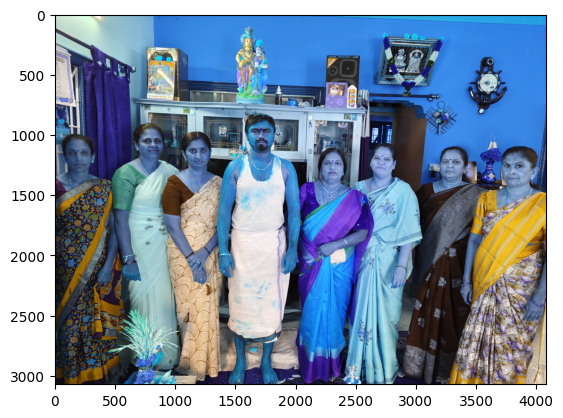

In [1]:
import cv2
import matplotlib.pyplot as plt

# Load cascades
face_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_eye.xml')

image = cv2.imread('./sample/img5.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image)

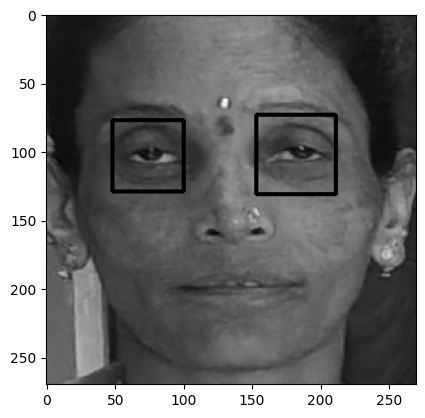

In [2]:
import cv2
import matplotlib.pyplot as plt

# Load cascades
face_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_eye.xml')

image = cv2.imread('./sample/img5.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

# Step 1: store cropped faces in a list
face_list = []
for (x, y, w, h) in faces:
    face_crop = gray[y:y+h, x:x+w]   # crop the face region
    face_list.append(face_crop)

# Step 2: loop through each face crop and detect eyes inside it
processed_faces = []
for face_crop in face_list:
    eyes = eye_cascade.detectMultiScale(face_crop, 1.3, 5)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(face_crop, (ex, ey), (ex+ew, ey+eh), (0,255,0), 2)
    processed_faces.append(face_crop)

# Show the first processed face
plt.imshow(processed_faces[1], cmap='gray')
plt.show()

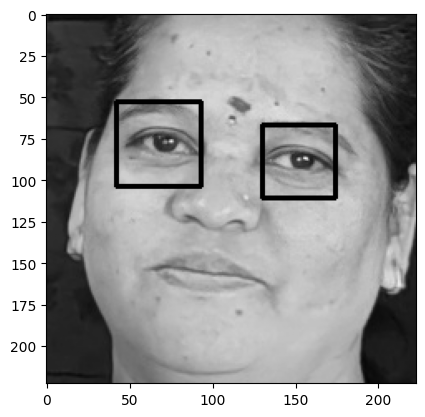

In [3]:
# Show the first processed face
plt.imshow(processed_faces[3], cmap='gray')
plt.show()

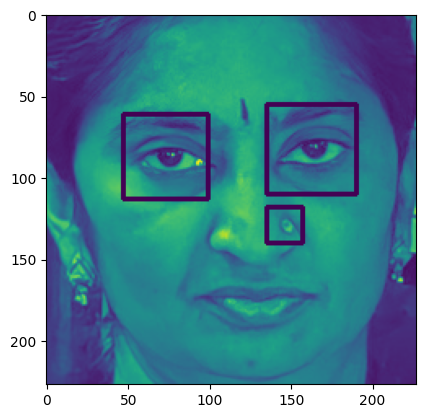

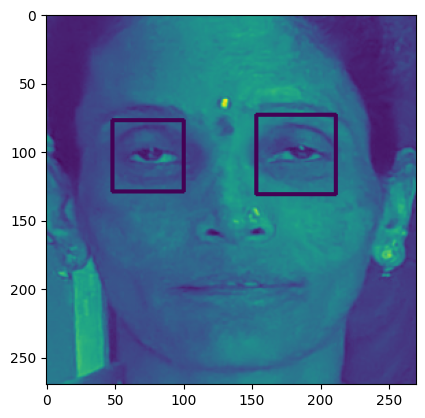

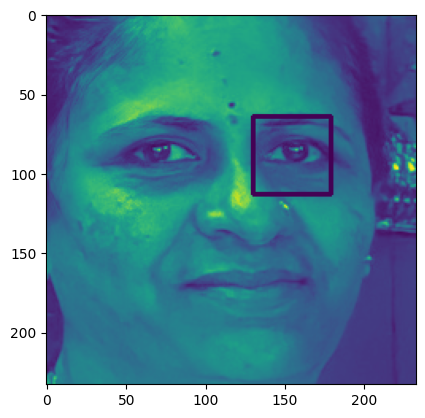

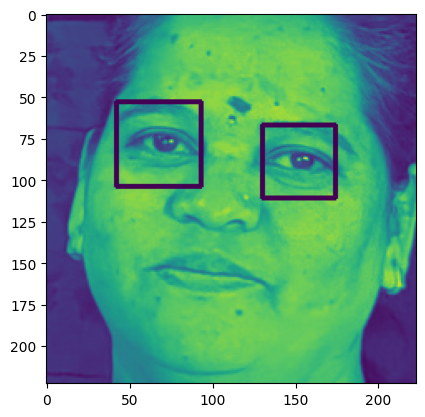

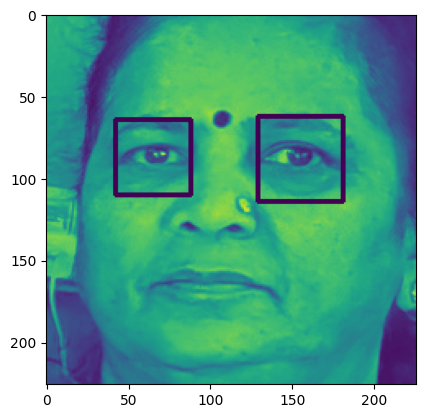

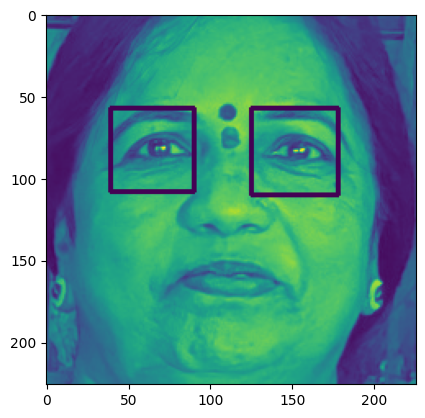

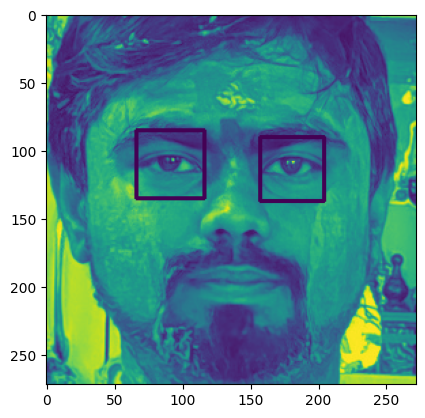

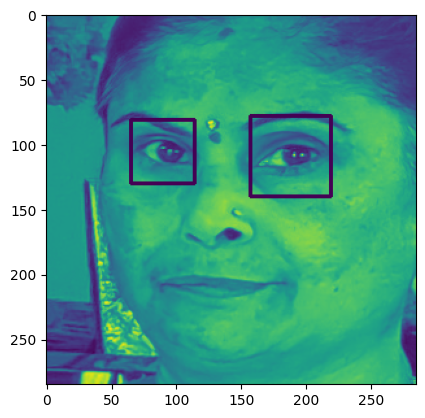

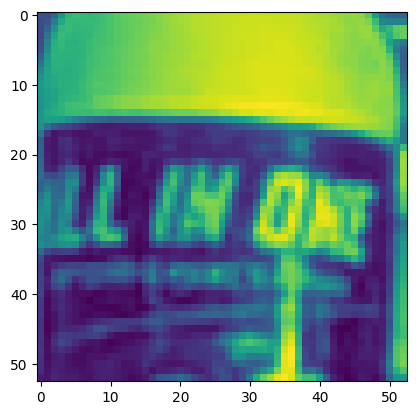

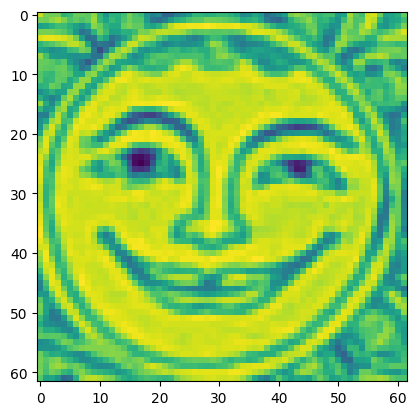

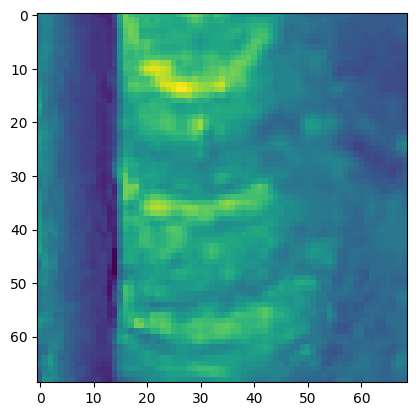

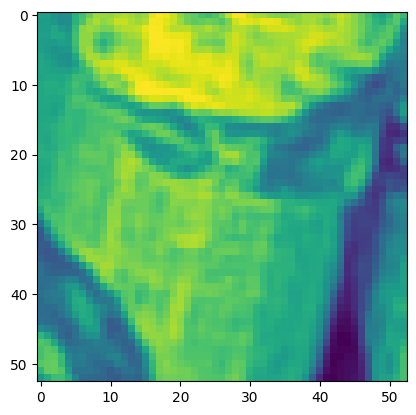

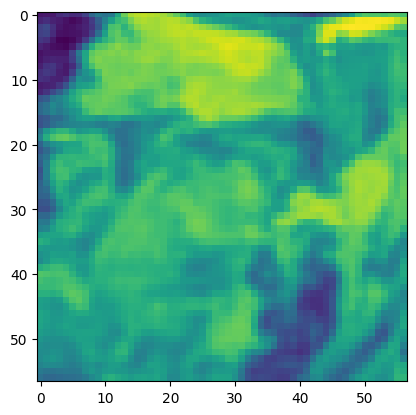

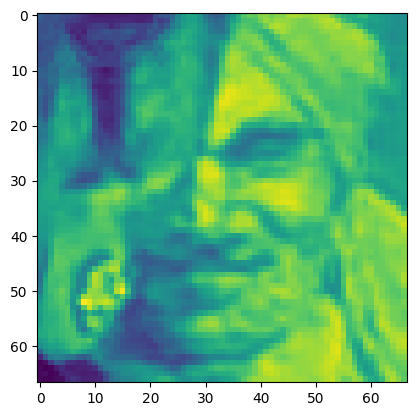

In [4]:
processed_faces
for i in range(len(processed_faces)):
    plt.imshow(processed_faces[i])
    plt.show()

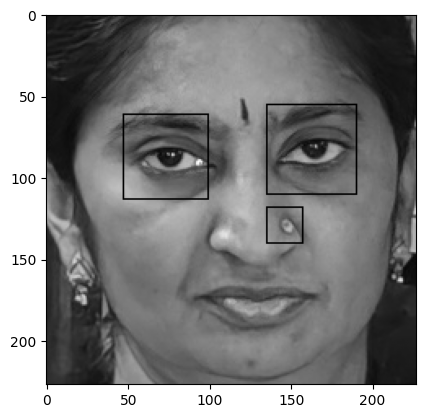

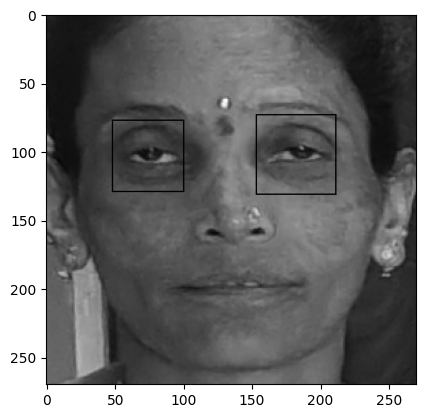

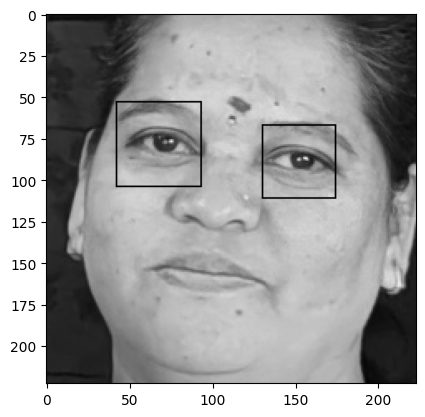

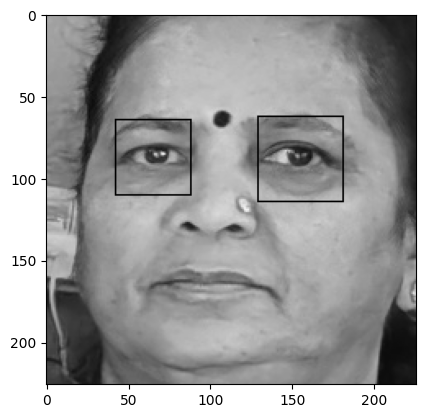

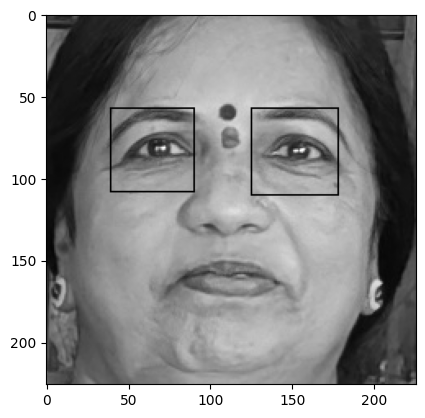

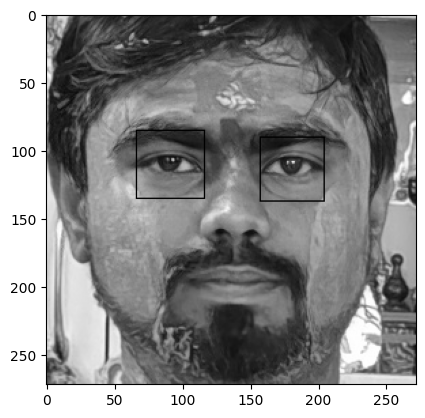

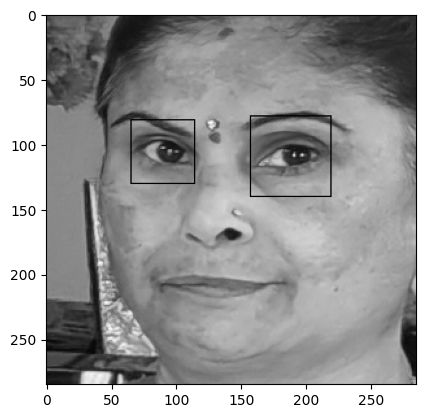

In [8]:
import cv2
import matplotlib.pyplot as plt

# Load cascades
face_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_eye.xml')

image = cv2.imread('./sample/img5.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

# Step 1: store cropped faces in a list
face_list = []
for (x, y, w, h) in faces:
    face_crop = gray[y:y+h, x:x+w]   # crop the face region
    face_list.append(face_crop)

# Step 2: loop through each face crop and detect eyes inside it
processed_faces = []
for face_crop in face_list:
    eyes = eye_cascade.detectMultiScale(face_crop, 1.3, 5)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(face_crop, (ex, ey), (ex+ew, ey+eh), (0,255,0), 1)
    if len(eyes) >=2:
        processed_faces.append(face_crop)

#processed_faces
for i in range(len(processed_faces)):
    plt.imshow(processed_faces[i], cmap='gray')
    plt.show()

In [13]:
path_to_data = "./Training_Images/"
path_to_cr_data = "./Crop_Images/"

In [14]:
import os
dir_name = []
for folder in os.scandir(path_to_data):
    if folder.is_dir():
        dir_name.append(folder.path)

In [15]:
dir_name

['./Training_Images/angelina_jolie',
 './Training_Images/darshan_thoogudeepa',
 './Training_Images/rukmini_vasanth',
 './Training_Images/tom_cruise',
 './Training_Images/will_smith']

In [28]:
import shutil
import os
if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [25]:
import cv2
import matplotlib.pyplot as plt
def get_face_multi(image_path):
    # Load cascades
    face_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_eye.xml')

    image = cv2.imread(image_path)
    #Adding a check point to skip the files which return error when the file in not read by the module
    if image is None:
        #print(f"⚠️ Skipping unreadable file: {image_path}")
        return None
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    # Step 1: store cropped faces in a list
    face_list = []
    for (x, y, w, h) in faces:
        face_crop = image[y:y+h, x:x+w]   # crop the face region
        face_list.append(face_crop)

    # Step 2: loop through each face crop and detect eyes inside it
    processed_faces = []
    for face_crop in face_list:
        eyes = eye_cascade.detectMultiScale(face_crop, 1.3, 5)
        #for (ex, ey, ew, eh) in eyes:
        #    cv2.rectangle(face_crop, (ex, ey), (ex+ew, ey+eh), (0,255,0), 1)
        if len(eyes) >=2:
            processed_faces.append(face_crop)

    #processed_faces
    for i in range(len(processed_faces)):
        return processed_faces[i]
        #plt.imshow(processed_faces[i], cmap='gray')
        #plt.show()

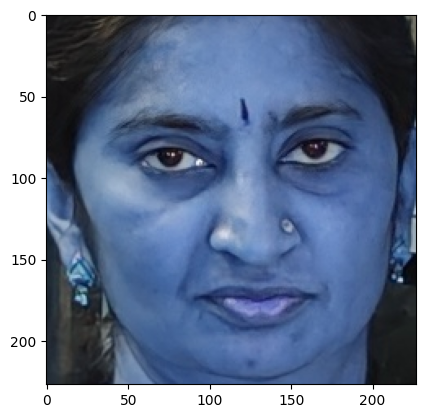

In [24]:
plt.imshow(get_face_multi('./sample/img5.jpg'))

In [29]:
cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in dir_name:
    count = 1
    celebrity_name = img_dir.split('/')[-1]
    print(celebrity_name)
    
    celebrity_file_names_dict[celebrity_name] = []
    
    for entry in os.scandir(img_dir):
        if entry.is_file(): 
            roi_color = get_face_multi(entry.path)
            if roi_color is not None:
                cropped_folder = path_to_cr_data + celebrity_name
                if not os.path.exists(cropped_folder):
                    os.makedirs(cropped_folder)
                    #cropped_image_dirs.append(cropped_folder)
                    print("Generating cropped images in folder: ",cropped_folder)
            
            #for face in roi_color:        
                cropped_file_name = celebrity_name + str(count) + ".png"
                cropped_file_path = cropped_folder + "/" + cropped_file_name 
                
                cv2.imwrite(cropped_file_path, roi_color)
                celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
                count += 1

angelina_jolie
Generating cropped images in folder:  ./Crop_Images/angelina_jolie
darshan_thoogudeepa
Generating cropped images in folder:  ./Crop_Images/darshan_thoogudeepa
rukmini_vasanth
Generating cropped images in folder:  ./Crop_Images/rukmini_vasanth
tom_cruise
Generating cropped images in folder:  ./Crop_Images/tom_cruise
will_smith
Generating cropped images in folder:  ./Crop_Images/will_smith
